In [3]:
import sys

print(sys.executable)

c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Scripts\python.exe


In [26]:
import copy, math, os, pickle, time, pandas as pd, numpy as np, scipy.stats as ss, pathlib as pl, gc

from pathlib import Path

from matplotlib import pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, average_precision_score, roc_auc_score, accuracy_score, f1_score, confusion_matrix
from sklearn.calibration import CalibrationDisplay

# import torch, torch.utils.data as utils, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
# from torch.autograd import Variable
# from torch.nn.parameter import Parameter

In [3]:
#GAP_TIME          = 6  # In hours.  I don't need this as there is already a gap between end of data and predicted outcome (at 7 days)
WINDOW_SIZE       = 49 # In hours.  For my project, this is 49 hours as I have 24 hours prior to ICU inttime, 24 hours in ICU.  
SEED              = 1
ID_COLS           = ['subject_id', 'hadm_id', 'icustay_id']
ID_COLS_HOURLY = ID_COLS + ['hours_in']
TESTING = True          # set False for the full cohort run
PROJECT_ROOT = Path.cwd().parents[0]   # adjust after checking Path.cwd()
print(PROJECT_ROOT)
FLAT_DATA_PATH = PROJECT_ROOT / 'results' / 'models' / 'flat_data.pkl'  # location to save the processed data (train/dev/test) for later model evaluation

np.random.seed(SEED)
#torch.manual_seed(SEED)

c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project


In [4]:
class DictDist():
    def __init__(self, dict_of_rvs): self.dict_of_rvs = dict_of_rvs
    def rvs(self, n):
        a = {k: v.rvs(n) for k, v in self.dict_of_rvs.items()}
        out = []
        for i in range(n): out.append({k: vs[i] for k, vs in a.items()})
        return out
    
class Choice():
    def __init__(self, options): self.options = options
    def rvs(self, n): return [self.options[i] for i in ss.randint(0, len(self.options)).rvs(n)]

In [5]:
import getpass
from sqlalchemy import create_engine

pg_user = 'postgres'      # same value you use to connect via psql
pg_host = 'localhost'          # or wherever your Postgres server is
pg_port = 5432
pg_dbname = 'mimiciv'

pg_password = getpass.getpass('Postgres password: ')

engine = create_engine(
    f'postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_dbname}'
)

In [6]:
df = pd.read_sql("SELECT current_database();", engine)
print(df)

  current_database
0          mimiciv


In [21]:
pd.read_sql('SELECT 1', engine)

,?column?
0,1


In [9]:
#del data_full_lvl2_imputed                      # Delete data_full_lvl2_imputed dataframe to save memory once the imputed version is created.
#gc.collect()

In [7]:
%%time

hourly_table = 'msc_project.sample_hourly_data' if TESTING else 'msc_project.hourly_data'
statics_table = 'msc_project.sample_allpatients' if TESTING else 'msc_project.allpatients'

hourly_query = f"SELECT * FROM {hourly_table}"
statics_query = f"SELECT * FROM {statics_table}"

data_full_lvl2 = (
    pd.read_sql(hourly_query, engine)
    .set_index(ID_COLS_HOURLY)
    .drop(columns='hour_end')   # dropping hour_end as it is redundant - hours_in tracks time since admission.
    .astype('float32')              # data type should be float (dealing with potential for all missing values). 
                                    # can specify float32 rather than default float64 to reduce memory usage.
)

statics = pd.read_sql(statics_query, engine).set_index(ID_COLS)

CPU times: total: 46.9 ms
Wall time: 82.7 ms


In [11]:
#data_full_lvl2.head()

In [12]:
#statics.head()

In [8]:
""""
Adapted from the MIMIC-Extract function 'simple_imputer' in mimic3benchmark.preprocessing.utils, which
deals with missing values in the hourly data. The original function takes a dataframe with a multi-index of 
(subject_id, hadm_id, icustay_id, hours_in) and columns with a multi-index of (label, LEVEL1, LEVEL2, 
Aggregation Function). The function fills in missing values for the 'mean' aggregation function using 
forward fill and the mean of the icustay, and creates a 'mask' column indicating whether the original value 
was present or not. It also calculates the time since the last measurement for each variable.

This adaptation takes a dataframe with only one column per variable for the mean per hour. This is indexed by 
the ID columns and hour. If there is no measurement in a given hour, it is supplied as NaN in the input. 

I have made a decision to forward fill the missing values, but not to fill missing values at the start with the 
mean. It seems incorrect to impute values for hours before the first measurement - I do not want to use measures from 
after the relevant time point to impute values for before the first measurement.

"""

def simple_imputer(df, id_cols=ID_COLS):

    df = df.copy()
    # NB the forward fill depends on hours_in being in order for each stay.
    df = df.sort_index()    # Therefore sort. The index has been set earlier to be the ID_COLS + ['hours_in'] for the hourly data.

    mask = df.notna().astype(float)    # see later for why we convert to float. This is the mask of whether a 
                                        # measurement was present or not.
    imputed = (
        df.groupby(level=id_cols).ffill()              # forward fills from the last measurement.
        .fillna(0)
    )

    # Planning to grouping by stay here, this will mean that the last observed time should be only within the stay, 
    # not across other stays as in the original notebook. 
    is_absent = 1 - mask                # This is now 1 if the measurement is absent, 0 if there is a measurement.
    total_hours_of_absence = is_absent.groupby(level=id_cols).cumsum()   # cumulative sum of hours with no measurement for the stay.
    absent_hours_before_last_measure = (
        total_hours_of_absence[is_absent == 0]
        .groupby(level=id_cols).ffill()   
    )   # This is the number of absent hours before the latest measurement. 
    hours_since_last_measure = (total_hours_of_absence - absent_hours_before_last_measure).fillna(100)  # 100 is beyond the max hours covered in my data.

    df_out = pd.concat(
        [imputed, mask, hours_since_last_measure],             # temporary - include all of the measures to review progress. 
        axis = 1,
        keys = ['mean', 'mask', 'hours_since_last_measure']     # rename imputed as mean to match the Wang pipeline code.
    )

    # Carrying out renaming and restructuring here to work with later code from the Wang pipeline.
    df_out.columns.names = ['Aggregation Function', 'variable']     # need top level names
    df_out = df_out.swaplevel(0, 1, axis=1)                           # swap levels so variable is top level, aggregation next, to match Wang pipeline.
    df_out.sort_index(axis=1, inplace=True)                             # sort index to be consistent with the Wang pipeline.

    return df_out

In [14]:
#test_output =simple_imputer(data_full_lvl2).head(50)
#test_output

In [15]:
#test_output.columns.names


In [9]:
""""
Adapted from the MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
in mimic3benchmark.preprocessing.utils, which splits the data into train, dev and test sets and also deals 
with standardisation. 
Updates compared to the original code:
- Removed the raw dataset as I am not using it.
- limited to a single outcome, length of stay after 7 days from ICU admission.
- No truncation based on the number of hours in the ICU, as this has already been done in my SQL processing.
- No use of GAP_TIME to ensure a gap between the end of the data and the predicted outcome, as there is already a gap between the last 
time point at 24 hours post-ICU admission and the predicted outcome at 7 days post ICU admission.
"""


Ys = statics[['los_icu']].copy()  # No need to filter for max_hours > WINDOW_SIZE + GAP_TIME as this check is done in the SQL query for the hourly data. GAP_TIME is not needed as there is already a gap between the end of the data and the predicted outcome (at 7 days). 
Ys['los_7'] = (Ys['los_icu'] > 7).astype(float) # Amending to convert to float - original line didn't modify Ys.
Ys.drop(columns=['los_icu'], inplace=True)  
#Ys.astype(float)

data_full_lvl2_imputed = simple_imputer(data_full_lvl2)     # Call simple_imputer() to get the structure expected in the Wang pipeline

lvl2 = data_full_lvl2_imputed[             # No requirement for a raw data set. No need to limit to values within WINDOW_SIZE.
                                    # to do - add a check for number of hours instead?
    (data_full_lvl2_imputed.index.get_level_values('icustay_id').isin(
        set(Ys.index.get_level_values('icustay_id'))
        )
        )
]
del data_full_lvl2                      # Delete data_full_lvl2 dataframe to save memory once the imputed version is created.
gc.collect()

train_frac, dev_frac, test_frac = 0.7, 0.1, 0.2
lvl2_subj_idx, Ys_subj_idx = [df.index.get_level_values('subject_id') for df in (lvl2, Ys)] # no raw dataset.
lvl2_subjects = set(lvl2_subj_idx)
assert lvl2_subjects == set(Ys_subj_idx), "Subject ID pools differ!"

np.random.seed(SEED)
subjects, N = np.random.permutation(list(lvl2_subjects)), len(lvl2_subjects)
N_train, N_dev, N_test = int(train_frac * N), int(dev_frac * N), int(test_frac * N)
train_subj = subjects[:N_train]
dev_subj   = subjects[N_train:N_train + N_dev]
test_subj  = subjects[N_train+N_dev:]

[(lvl2_train, lvl2_dev, lvl2_test), (Ys_train, Ys_dev, Ys_test)] = [     # again no raw dataset.
    [df[df.index.get_level_values('subject_id').isin(s)] for s in (train_subj, dev_subj, test_subj)] \
    for df in (lvl2, Ys)
]

idx = pd.IndexSlice
lvl2_means, lvl2_stds = lvl2_train.loc[:, idx[:,'mean']].mean(axis=0), lvl2_train.loc[:, idx[:,'mean']].std(axis=0)  
# std is zero for some variables - need to deal with this.
# If std is zero, can replace with 1 to avoid division by zero in the below standardisation step. 
lvl2_stds = lvl2_stds.replace(0, 1)

lvl2_train.loc[:, idx[:,'mean']] = (lvl2_train.loc[:, idx[:,'mean']] - lvl2_means)/lvl2_stds
lvl2_dev.loc[:, idx[:,'mean']] = (lvl2_dev.loc[:, idx[:,'mean']] - lvl2_means)/lvl2_stds
lvl2_test.loc[:, idx[:,'mean']] = (lvl2_test.loc[:, idx[:,'mean']] - lvl2_means)/lvl2_stds

# adding the same process for hours since last measure, to avoid problems with scale:
hslm_means, hslm_stds = lvl2_train.loc[:, idx[:, 'hours_since_last_measure']].mean(axis=0), lvl2_train.loc[:, idx[:, 'hours_since_last_measure']].std(axis=0),
hslm_stds = hslm_stds.replace(0, 1)

lvl2_train.loc[:, idx[:, 'hours_since_last_measure']] = (lvl2_train.loc[:, idx[:, 'hours_since_last_measure']] - hslm_means)/hslm_stds
lvl2_dev.loc[:, idx[:,'hours_since_last_measure']] = (lvl2_dev.loc[:, idx[:,'hours_since_last_measure']] - hslm_means)/hslm_stds
lvl2_test.loc[:, idx[:,'hours_since_last_measure']] = (lvl2_test.loc[:, idx[:,'hours_since_last_measure']] - hslm_means)/hslm_stds



In [10]:
# raw_train, raw_dev, raw_test, lvl2_train, lvl2_dev, lvl2_test = [                 # no need to call simple_imputer() here, as it's been called earlier on the full dataset.
#     simple_imputer(df) for df in (raw_train, raw_dev, raw_test, lvl2_train, lvl2_dev, lvl2_test)
# ]
lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test = [                                  # removed the raw datasets.
    df.pivot_table(index=['subject_id', 'hadm_id', 'icustay_id'], columns=['hours_in']) for df in (
        lvl2_train, lvl2_dev, lvl2_test
    )
]

for df in lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test: assert not df.isnull().any().any()       # removed the raw datasets.

# save the processed flat data for later model evaluation. 
with open(FLAT_DATA_PATH, mode = 'wb') as f:
    pickle.dump({
        'lvl2_flat_train': lvl2_flat_train,
        'lvl2_flat_dev': lvl2_flat_dev,
        'lvl2_flat_test': lvl2_flat_test,
        'Ys_train': Ys_train,
        'Ys_dev': Ys_dev,
        'Ys_test': Ys_test
    }, f)

Task prediction

Hyperparameters

In [11]:
""""
Adapted from the MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
in mimic3benchmark.preprocessing.utils, which sets up hyperparameter distributions for logistic regression, random forest and GRU models.
To start with, I will set up only logistic regression and random forest models. I will begin using the same hyperparameters before 
considering adjustments.
"""

N = 15

LR_dist = DictDist({
    'C': Choice(np.geomspace(1e-3, 1e3, 10000)),
    'penalty': Choice(['l1', 'l2']),
    'solver': Choice(['liblinear', 'lbfgs']),
    'max_iter': Choice([100, 500])
})
np.random.seed(SEED)
LR_hyperparams_list = LR_dist.rvs(N)
for i in range(N):
    if LR_hyperparams_list[i]['solver'] == 'lbfgs': LR_hyperparams_list[i]['penalty'] = 'l2'

RF_dist = DictDist({
    'n_estimators': ss.randint(50, 500),
    'max_depth': ss.randint(2, 10),
    'min_samples_split': ss.randint(2, 75),
    'min_samples_leaf': ss.randint(1, 50),
})
np.random.seed(SEED)
RF_hyperparams_list = RF_dist.rvs(N)


Functions

In [12]:
'''
These functions are from a MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
I have created an additional function select_hyperparameters() that does not move on to runnig the model on the test data
This will be used for initial exploration and decision making on hyperparameters to be sure of avoiding leakage.
Average precision score is used instead of roc_auc to choose hyperparameters.

'''

def select_hyperparameters(model, hyperparams_list, X_flat_train, X_flat_dev, target):
    '''
    This function is an addition to use to determine hyperparameters, which only runs the models 
    on the Dev dataset, not Test.
    Average precision score is used instead of roc_auc to choose hyperparameters.
    This is a better measure for the outcome which has a significant class imbalance.
    '''
    best_s, best_hyperparams = -np.inf, None
    for i, hyperparams in enumerate(hyperparams_list):
        print("On sample %d / %d (hyperparams = %s)" % (i+1, len(hyperparams_list), repr((hyperparams))))
        M = model(**hyperparams)
        M.fit(X_flat_train, Ys_train[target])
        s = average_precision_score(Ys_dev[target], M.predict_proba(X_flat_dev)[:, 1])
        if s > best_s:
            best_s, best_hyperparams, best_M = s, hyperparams, M
            print("New Best Score: %.2f @ hyperparams = %s" % (100*best_s, repr((best_hyperparams))))
    y_true  = Ys_dev[target]
    y_score = best_M.predict_proba(X_flat_dev)[:, 1]
    y_pred  = best_M.predict(X_flat_dev)

    auc   = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    acc   = accuracy_score(y_true, y_pred)
    F1    = f1_score(y_true, y_pred)
    return best_M, best_hyperparams, auc, auprc, acc, F1

def run_basic(model, hyperparams_list, X_flat_train, X_flat_dev, X_flat_test, target):
    '''
    This may be run, with adjustments, after initial decision making on hyperparameters
    '''
    best_s, best_hyperparams = -np.inf, None
    for i, hyperparams in enumerate(hyperparams_list):
        print("On sample %d / %d (hyperparams = %s)" % (i+1, len(hyperparams_list), repr((hyperparams))))
        M = model(**hyperparams)
        M.fit(X_flat_train, Ys_train[target])
        s = roc_auc_score(Ys_dev[target], M.predict_proba(X_flat_dev)[:, 1])
        if s > best_s:
            best_s, best_hyperparams = s, hyperparams
            print("New Best Score: %.2f @ hyperparams = %s" % (100*best_s, repr((best_hyperparams))))

    return run_only_final(model, best_hyperparams, X_flat_train, X_flat_dev, X_flat_test, target)

def run_only_final(model, best_hyperparams, X_flat_train, X_flat_dev, X_flat_test, target):
    '''
    this may be run, with adjustments, after initial decision making on hyperparameters
    '''
    best_M = model(**best_hyperparams)
    best_M.fit(pd.concat((X_flat_train, X_flat_dev)), pd.concat((Ys_train, Ys_dev))[target])
    y_true  = Ys_test[target]
    y_score = best_M.predict_proba(X_flat_test)[:, 1]
    y_pred  = best_M.predict(X_flat_test)

    auc   = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    acc   = accuracy_score(y_true, y_pred)
    F1    = f1_score(y_true, y_pred)
    
    return best_M, best_hyperparams, auc, auprc, acc, F1

Sklearn

In [13]:
""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
Added exception handling for the case where the results file does not exist yet.
"""

RESULTS_PATH = PROJECT_ROOT / 'results' / 'models' / 'extraction_baselines-sklearn.pkl'

try:
    with open(RESULTS_PATH, mode='rb') as f: 
        results = pickle.load(f)
except FileNotFoundError:
    results = {}

RERUN = True

In [14]:
""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
I have made an adapted version of the cell where models are run. 
I am adapting the code to run only on the outcome length of stay 7 days after ICU admission, and to run only on 
the lvl2 representation of the data, not the raw version.
At this stage in the development of the project the models will only be run using the Dev dataset, not Test.

"""

for model_name, model, hyperparams_list in [
    ('RF', RandomForestClassifier, RF_hyperparams_list), ('LR', LogisticRegression, LR_hyperparams_list)
    ]:
    if model_name not in results:                           # no need for loop around outcomes as I have only one.
        results[model_name] = {}                            # retaining loop around representations. Although I don'have a raw dataset, I will have a separate representation at a later stage.
    for n, X_flat_train, X_flat_dev in (
        ('lvl2', lvl2_flat_train, lvl2_flat_dev),  # retaining comma as this is a tuple with addition of another representation later
        ):
        print("Running model %s on target %s with representation %s" % (model_name, 'los_7', n)) 
        results[model_name][n] = select_hyperparameters(model, hyperparams_list, X_flat_train, X_flat_dev, 'los_7')
        print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
        print(results[model_name][n][2:])
        with open(RESULTS_PATH, mode='wb') as f: 
            pickle.dump(results, f)
        print(results[model_name][n])

Running model RF on target los_7 with representation lvl2
On sample 1 / 15 (hyperparams = {'n_estimators': np.int64(87), 'max_depth': np.int64(3), 'min_samples_split': np.int64(15), 'min_samples_leaf': np.int64(8)})
New Best Score: 100.00 @ hyperparams = {'n_estimators': np.int64(87), 'max_depth': np.int64(3), 'min_samples_split': np.int64(15), 'min_samples_leaf': np.int64(8)}
On sample 2 / 15 (hyperparams = {'n_estimators': np.int64(285), 'max_depth': np.int64(4), 'min_samples_split': np.int64(11), 'min_samples_leaf': np.int64(4)})
On sample 3 / 15 (hyperparams = {'n_estimators': np.int64(446), 'max_depth': np.int64(6), 'min_samples_split': np.int64(9), 'min_samples_leaf': np.int64(7)})
On sample 4 / 15 (hyperparams = {'n_estimators': np.int64(122), 'max_depth': np.int64(8), 'min_samples_split': np.int64(65), 'min_samples_leaf': np.int64(22)})
On sample 5 / 15 (hyperparams = {'n_estimators': np.int64(305), 'max_depth': np.int64(7), 'min_samples_split': np.int64(63), 'min_samples_leaf'

c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

On sample 3 / 15 (hyperparams = {'C': np.float64(0.003491839757169992), 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 500})
On sample 4 / 15 (hyperparams = {'C': np.float64(48.783036208459954), 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 100})
On sample 5 / 15 (hyperparams = {'C': np.float64(0.05459762073728651), 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 500})


c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

On sample 6 / 15 (hyperparams = {'C': np.float64(1.081193410945589), 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 100})
On sample 7 / 15 (hyperparams = {'C': np.float64(0.0012201371230349724), 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 100})
On sample 8 / 15 (hyperparams = {'C': np.float64(0.3429679403524682), 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 500})
On sample 9 / 15 (hyperparams = {'C': np.float64(44.77804273778909), 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 500})


...

On sample 10 / 15 (hyperparams = {'C': np.float64(0.11951096159304532), 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 100})
On sample 11 / 15 (hyperparams = {'C': np.float64(433.47464177487655), 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 500})
On sample 12 / 15 (hyperparams = {'C': np.float64(1.7295128471299193), 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 500})


c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

On sample 13 / 15 (hyperparams = {'C': np.float64(1.6777315525707752), 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 500})
On sample 14 / 15 (hyperparams = {'C': np.float64(0.059893230394471704), 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 500})
On sample 15 / 15 (hyperparams = {'C': np.float64(0.032340816118081595), 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 100})


c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

Final results for model LR on target los_7 with representation lvl2
(1.0, 1.0, 0.6, 0.0)
(LogisticRegression(C=np.float64(0.001383611303681924), max_iter=500,
                   penalty='l2', solver='liblinear'), {'C': np.float64(0.001383611303681924), 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 500}, 1.0, 1.0, 0.6, 0.0)


In [ ]:
""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
This is the cell where the models are run. 
I am adapting the code to run only on the outcome length of stay 7 days after ICU admission, and to run only on 
the lvl2 representation of the data, not the raw version.
However this will only be used when the design decisions and hyperparameter selection are complete, to avoid
exploration and development occuring using the Test dataset.
"""

# for model_name, model, hyperparams_list in [
#     ('RF', RandomForestClassifier, RF_hyperparams_list), ('LR', LogisticRegression, LR_hyperparams_list)
#     ]:
#     if model_name not in results:                           # no need for loop around outcomes as I have only one.
#         results[model_name] = {}                            # retaining loop around representations. Although I don'have a raw dataset, I will have a separate representation at a later stage.
#     for n, X_flat_train, X_flat_dev, X_flat_test in (
#         ('lvl2', lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test),  # retaining comma as this is a tuple with addition of another representation later
#         ):
#         if n in results[model_name]:
#             print("Finished model %s on target %s with representation %s" % (model_name, 'los_7', n))
#             if RERUN:
#                 h = results[model_name][n][1]       # gets the previous hyperparameters for that model and representation.
#                 results[model_name][n] = run_only_final(model, h, X_flat_train, X_flat_dev, X_flat_test, 'los_7')
#                 print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
#                 print(results[model_name][n][2:])

#                 with open(RESULTS_PATH, mode='wb') as f: pickle.dump(results, f)
#             continue
#         print("Running model %s on target %s with representation %s" % (model_name, 'los_7', n))    # this is what happens if not yet run
#         results[model_name][n] = run_basic(model, hyperparams_list, X_flat_train, X_flat_dev, X_flat_test, 'los_7')
#         print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
#         print(results[model_name][n][2:])
#         with open(RESULTS_PATH, mode='wb') as f: 
#             pickle.dump(results, f)

Finished model RF on target los_7 with representation lvl2
Final results for model RF on target los_7 with representation lvl2
(0.7259992405215587, 0.31532763908237094, 0.8594032980650081, 0.0)
Finished model LR on target los_7 with representation lvl2


c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Final results for model LR on target los_7 with representation lvl2
(0.7595744664851939, 0.33882518168731457, 0.8571156229148794, 0.17319360176503035)


In [15]:
# review results

summary_dict = {}
for model_name in results:
    summary_dict[model_name] = {
        'AUC-ROC': results[model_name]['lvl2'][2],
        'AUPRC': results[model_name]['lvl2'][3],
        'Accuracy': results[model_name]['lvl2'][4],
        'F1': results[model_name]['lvl2'][5],
    }
summary_dict

{'RF': {'AUC-ROC': 1.0, 'AUPRC': 1.0, 'Accuracy': 0.6, 'F1': 0.0},
 'LR': {'AUC-ROC': 1.0, 'AUPRC': 1.0, 'Accuracy': 0.6, 'F1': 0.0}}

In [29]:
# look at class imbalance in my sample data
print(Ys_train['los_7'].value_counts())
print(Ys_dev['los_7'].value_counts())
print(Ys_test['los_7'].value_counts())

los_7
0.0    32
1.0     3
Name: count, dtype: int64
los_7
0.0    3
1.0    2
Name: count, dtype: int64
los_7
0.0    10
Name: count, dtype: int64


In [ ]:
# confusion matrix and plots for both RF and LR together

# this doesn't work - go back to it later.

# for model_name in ('RF', 'LR'):
#     best_M = results[model_name]['lvl2'][0]
#     y_true = Ys_dev['los_7']            # should be looking at dev not test
#     y_pred = best_M.predict(lvl2_flat_dev)  # should be looking at dev not test
#     y_prob = best_M.predict_proba(lvl2_flat_dev)[:, 1]

#     # confusion matrix:
#     matrix[model_name] = confusion_matrix(y_true, y_pred, labels = [0.0,1.0])

#     # calibration plot
#     calib_plot[model_name] = CalibrationDisplay.from_predictions(y_true, y_prob, name = model_name)

#     # auc-roc
#     auc_roc_plot[model_name] = RocCurveDisplay.from_predictions(y_true, y_prob, name = model_name)

#     # au-prc
#     au_prc_plot[model_name] = PrecisionRecallDisplay.from_predictions(y_true, y_prob, name = model_name)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

[[3 0]
 [2 0]]


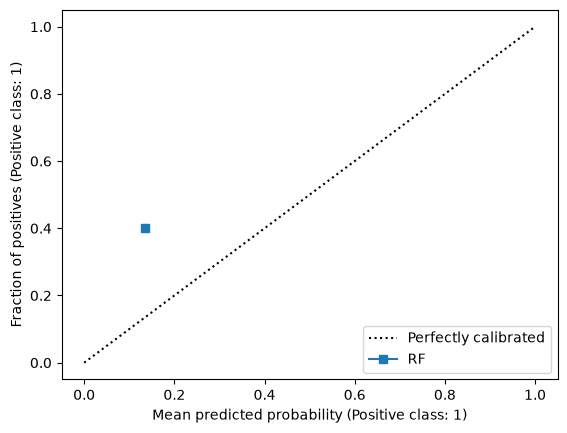

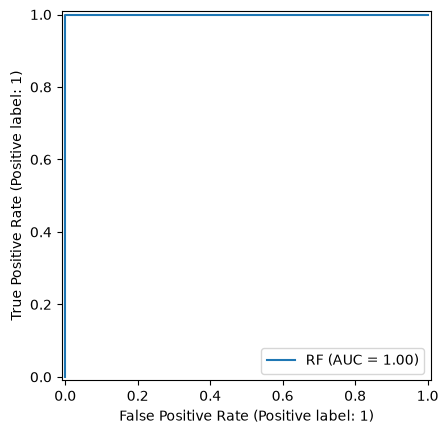

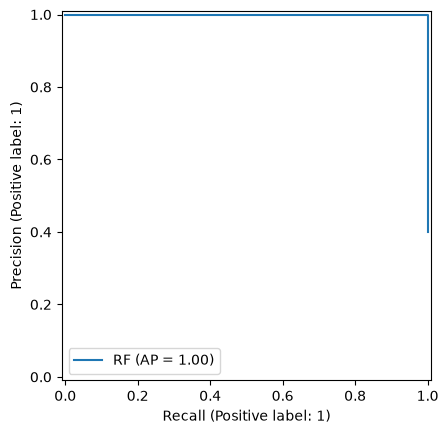

In [22]:
# confusion matrix for RF:
best_M = results['RF']['lvl2'][0]
y_true = Ys_dev['los_7']            # should be looking at dev not test
y_pred = best_M.predict(lvl2_flat_dev)  # should be looking at dev not test
y_prob = best_M.predict_proba(lvl2_flat_dev)[:, 1]

matrix = confusion_matrix(y_true, y_pred, labels = [0.0,1.0])
print(matrix)

calib_plot_RF = CalibrationDisplay.from_predictions(y_true, y_prob, name = 'RF')
plt.show()

# auc-roc
auc_roc_plot = RocCurveDisplay.from_predictions(y_true, y_prob, name = 'RF')
plt.show()

# au-prc
au_prc_plot = PrecisionRecallDisplay.from_predictions(y_true, y_prob, name = 'RF')
plt.show()

[[3 0]
 [2 0]]


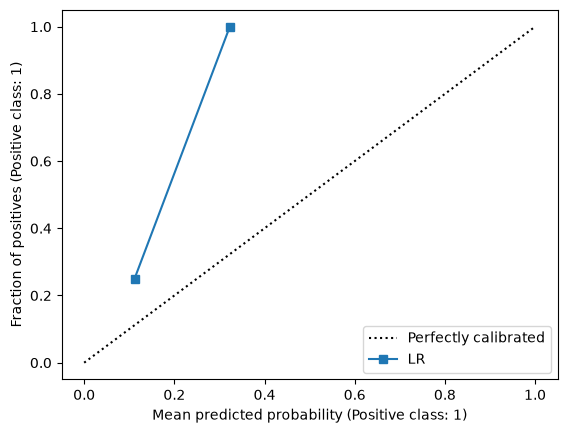

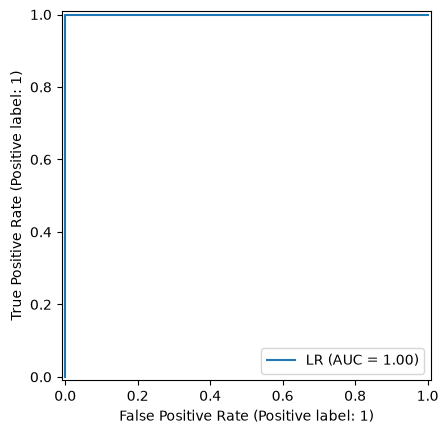

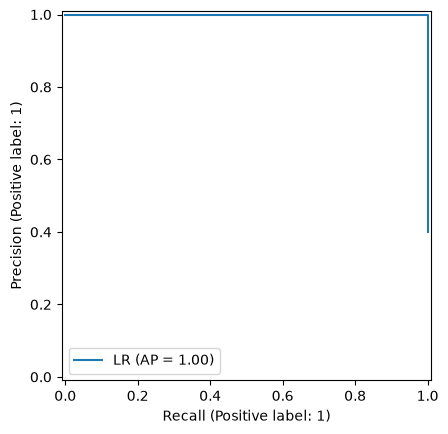

In [23]:
# confusion matrix and calibration plot for LR:
best_M = results['LR']['lvl2'][0]
y_true = Ys_dev['los_7']            # should be looking at dev not test
y_pred = best_M.predict(lvl2_flat_dev)    # should be looking at dev not test
y_prob = best_M.predict_proba(lvl2_flat_dev)[:, 1]

matrix = confusion_matrix(y_true, y_pred, labels = [0.0,1.0])
print(matrix)

calib_plot_lr = CalibrationDisplay.from_predictions(y_true, y_prob, name = 'LR')
plt.show()

# auc-roc
auc_roc_plot = RocCurveDisplay.from_predictions(y_true, y_prob, name = 'LR')
plt.show()

# au-prc
au_prc_plot = PrecisionRecallDisplay.from_predictions(y_true, y_prob, name = 'LR')
plt.show()

In [32]:
y_prob = best_M.predict_proba(lvl2_flat_test)[:, 1]

pd.Series(y_prob).describe()


count    10.000000
mean      0.077186
std       0.034210
min       0.048878
25%       0.059434
50%       0.063800
75%       0.075726
max       0.160109
dtype: float64

In [ ]:
# find optimum threshold for sensitivity/specificity based on F1 score: LR

best_M = results['LR']['lvl2'][0]
y_true = Ys_dev['los_7']            # should be looking at dev not test
y_prob = best_M.predict_proba(lvl2_flat_dev)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
print(precision)

print(recall)

print(thresholds)

f1 = 2 * ((precision * recall) / (precision + recall))

print(f1)


[0.4        0.5        0.66666667 1.         1.         1.        ]
[1.  1.  1.  1.  0.5 0. ]
[0.05659386 0.06957846 0.13246893 0.18834306 0.32303636]
[0.57142857 0.66666667 0.8        1.         0.66666667 0.        ]
